# PIPELINE PER LA CLASSIFICAZIONE DELLE PRIORITA' DEI TICKET

# 1. Importazione delle librerie

In [30]:
import pandas as pd # Serve per leggere e gestire i CSV
import re

from sklearn.feature_extraction.text import TfidfVectorizer # Trasforma il testo in numeri
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
) # Serve per valutare il modello
import matplotlib.pyplot as plt # Serve per la matrice di confusione

# 2. Caricamento dei Dataset e conversione in DataFrame Pandas

In [31]:
# Verifica del caricamento del dataset training
df_train = pd.read_csv('dataset_ticket_train.csv')

# Verifica del caricamento del dataset validation
df_valid = pd.read_csv('dataset_ticket_valid.csv')

# Verifica del caricamento del dataset test
df_test = pd.read_csv('dataset_ticket_test.csv')

# Verifica del caricamento dei dataset
print('Train:', df_train.shape, df_train['priority'].value_counts())
print('Valid:', df_valid.shape, df_valid['priority'].value_counts())
print('Test:', df_test.shape, df_test['priority'].value_counts())

Train: (398, 5) priority
media    193
alta     149
bassa     56
Name: count, dtype: int64
Valid: (50, 5) priority
media    23
alta     18
bassa     9
Name: count, dtype: int64
Test: (50, 5) priority
media    23
alta     21
bassa     6
Name: count, dtype: int64


# 3. Controllo colonne e dati CSV

In [32]:
print("Colonne presenti correttamente:")
print(df_train.columns.tolist())

print("\nPrime righe del dataset di training:")
display(df_train.head())

print("Priorità nel Train:")
print(df_train["priority"].value_counts())

print("\nPriorità nel Valid:")
print(df_valid["priority"].value_counts())

print("\nPriorità nel Test:")
print(df_test["priority"].value_counts())

Colonne presenti correttamente:
['id', 'title', 'body', 'category', 'priority']

Prime righe del dataset di training:


,id,title,body,category,priority
0,01x9wgci,Pagamento Q1 2024 in sospeso,L'importo per l'abbonamento trimestrale è stat...,Amministrazione,alta
1,qx657knm,Tempi di consegna per consulenza strategica,Serve conferma dei lead time per con contratto...,Commerciale,media
2,r58ho8z1,Interruzione servizio upload file,L'utilizzo di con credenziali corrette causa l...,Tecnico,bassa
3,xt76qm72,Documentazione contabile canone mensile,Potete fornire la documentazione amministrativ...,Amministrazione,bassa
4,5na9hcgl,Richiesta fattura per trimestre chiuso,Potete controllare se la fattura contratto n. ...,Amministrazione,media


Priorità nel Train:
priority
media    193
alta     149
bassa     56
Name: count, dtype: int64

Priorità nel Valid:
priority
media    23
alta     18
bassa     9
Name: count, dtype: int64

Priorità nel Test:
priority
media    23
alta     21
bassa     6
Name: count, dtype: int64


# 4. Preparazione dei dati

In [33]:
# Dataset train
x_train = df_train["title"] + " " + df_train["body"]
y_train_priorita = df_train["priority"]

# Dataset validation
x_valid = df_valid["title"] + " " + df_valid["body"]
y_valid_priorita = df_valid["priority"]

# Dataset test
x_test = df_test["title"] + " " + df_test["body"]
y_test_priorita = df_test["priority"]

# 5. Preprocessing del testo

In [34]:
# Pulizia di base del testo
def pulisci_testo(testo):
    testo = testo.lower()
    testo = re.sub(r"[^\w\s]", " ", testo)
    testo = re.sub(r"\s+", " ", testo)
    testo = testo.strip()
    return testo

x_train = x_train.apply(pulisci_testo)
x_valid = x_valid.apply(pulisci_testo)
x_test = x_test.apply(pulisci_testo)

print("Esempio di testo dopo il preprocessing")
print(x_train.iloc[0])

Esempio di testo dopo il preprocessing
pagamento q1 2024 in sospeso l importo per l abbonamento trimestrale è stato addebitato ma non risulta a sistema serve un controllo


# 6. Creazione pipeline TF-IDF e Logistic Regression priorità

In [35]:
# Creazione della pipeline per la classificazione delle priorità
pipeline_priorita = Pipeline([

    # Trasformazione del testo in valori numerici tramite TF-IDF
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2)
    )),

    # Creazione del modello di classificazione Logistic Regression
    ("logreg", LogisticRegression(
        max_iter=1000
    ))
])

# Verifica della corretta creazione della pipeline
print("Pipeline per la classificazione delle priorità creata correttamente.")

Pipeline per la classificazione delle priorità creata correttamente.


# 7. Addestramento del modello

In [36]:
# Ricerca dei migliori parametri per la priorità

parametri_priorita = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "logreg__C": [0.1, 1, 10]
}

grid_search_priorita = GridSearchCV(
    pipeline_priorita,
    parametri_priorita,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# Addestramento della Grid Search sul training set
grid_search_priorita.fit(x_train, y_train_priorita)

# Visualizzazione dei migliori parametri trovati
print("Migliori parametri per la priorità:")
print(grid_search_priorita.best_params_)
print("Miglior F1 macro ottenuto in cross-validation:",
      round(grid_search_priorita.best_score_, 4))

Migliori parametri per la priorità:
{'logreg__C': 10, 'tfidf__ngram_range': (1, 1)}
Miglior F1 macro ottenuto in cross-validation: 0.5839


# 8. Valutazione validation e test set

In [37]:
# Previsione della priorità sul validation set
y_valid_pred_priorita = grid_search_priorita.predict(x_valid)
# Calcolo Accuracy del validation
accuracy_valid_priorita = accuracy_score(y_valid_priorita, y_valid_pred_priorita)
# Calcolo F1 macro del validation
f1_valid_priorita = f1_score(
    y_valid_priorita,
    y_valid_pred_priorita,
    average="macro"
)

print("Risultati VALIDATION - PRIORITÀ")
print("Accuracy:", round(accuracy_valid_priorita, 4))
print("F1 macro:", round(f1_valid_priorita, 4))

print("Classification report - VALIDATION")
print(classification_report(y_valid_priorita, y_valid_pred_priorita))


# Previsione della priorità sul test set
y_test_pred_priorita = grid_search_priorita.predict(x_test)
# Calcolo Accuracy del test
accuracy_test_priorita = accuracy_score(
    y_test_priorita,
    y_test_pred_priorita
)
# Calcolo F1 macro del test
f1_test_priorita = f1_score(
    y_test_priorita,
    y_test_pred_priorita,
    average="macro"
)

print("Risultati TEST - PRIORITÀ")
print("Accuracy:", round(accuracy_test_priorita, 4))
print("F1 macro:", round(f1_test_priorita, 4))

print("Classification report - TEST")
print(classification_report(y_test_priorita, y_test_pred_priorita))

Risultati VALIDATION - PRIORITÀ
Accuracy: 0.62
F1 macro: 0.61
Classification report - VALIDATION
              precision    recall  f1-score   support

        alta       0.59      0.72      0.65        18
       bassa       0.80      0.44      0.57         9
       media       0.61      0.61      0.61        23

    accuracy                           0.62        50
   macro avg       0.67      0.59      0.61        50
weighted avg       0.64      0.62      0.62        50

Risultati TEST - PRIORITÀ
Accuracy: 0.82
F1 macro: 0.7965
Classification report - TEST
              precision    recall  f1-score   support

        alta       0.86      0.86      0.86        21
       bassa       0.62      0.83      0.71         6
       media       0.86      0.78      0.82        23

    accuracy                           0.82        50
   macro avg       0.78      0.82      0.80        50
weighted avg       0.83      0.82      0.82        50



# 9. Creazione matrice di confusione

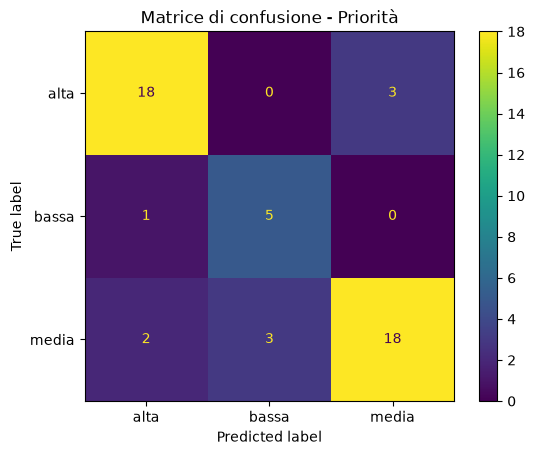

In [38]:
# Calcolo della matrice di confusione sul test set
cm_priorita = confusion_matrix(
    y_test_priorita,
    y_test_pred_priorita
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_priorita,
    display_labels=grid_search_priorita.classes_
)

# Visualizzazione della matrice
disp.plot()

plt.title("Matrice di confusione - Priorità")
plt.show()

# 10. Controllo overfitting

In [39]:
# Previsione della priorità sul training set
y_train_pred_priorita = grid_search_priorita.predict(x_train)

# Calcolo Accuracy del training
accuracy_train_priorita = accuracy_score(
    y_train_priorita,
    y_train_pred_priorita
)

# Calcolo F1 macro sul training
f1_train_priorita = f1_score(
    y_train_priorita,
    y_train_pred_priorita,
    average="macro"
)

print("Accuracy TRAIN:", round(accuracy_train_priorita, 4))
print("F1 macro TRAIN:", round(f1_train_priorita, 4))

print("\nAccuracy TEST:", round(accuracy_test_priorita, 4))
print("F1 macro TEST:", round(f1_test_priorita, 4))

print("\nDifferenza Accuracy train-test:",
      round(accuracy_train_priorita - accuracy_test_priorita, 4))

print("Differenza F1 train-test:",
      round(f1_train_priorita - f1_test_priorita, 4))

Accuracy TRAIN: 0.9497
F1 macro TRAIN: 0.9483

Accuracy TEST: 0.82
F1 macro TEST: 0.7965

Differenza Accuracy train-test: 0.1297
Differenza F1 train-test: 0.1518


In [40]:
# Salvataggio del modello definitivo
import joblib

modello_priorita_definitivo = grid_search_priorita.best_estimator_

joblib.dump(
    modello_priorita_definitivo,
    "Logistic_Regression_definitiva_priorita.pkl"
)

print("Modello definitivo per la classificazione delle priorità salvato correttamente.")

Modello definitivo per la classificazione delle priorità salvato correttamente.
